In [14]:
# FIX 6: Set PyTorch memory allocator env var BEFORE importing torch
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
# FIX 7: Import both odeint (standard autograd) and odeint_adjoint.
# odeint_adjoint is memory-efficient but only tracks gradients through registered
# nn.Module parameters. odeint builds a full autograd graph, needed when
# brain_drive_full must carry gradients back to ecg_to_osc_mlp.
from torchdiffeq import odeint, odeint_adjoint
import gc
import mne
import time
import sys

# --- Debugging Flags ---
use_half_precision = False
debug_interval = 100

# ---------- DATA LOADING + PREPROCESSING ----------
try:
    file_new_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
    raw = mne.io.read_raw_fif(file_new_raw, preload=False)
    data, times = raw[322, 2000:4000]
    ecg_data = -data[0]

    mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
    eeg_data = mat['Value'][:, 2000:4000]
    sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
    sc_matrix = sc_data["sc"]

    max_val = np.max(sc_matrix)
    Sw_all = (sc_matrix / max_val) * 0.01 if max_val > 0 else sc_matrix

except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    sys.exit()

non_zero_indices_per_row = [np.nonzero(Sw_all[i, :])[0] for i in range(Sw_all.shape[0])]

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

ecg_processed = preprocess_signal(ecg_data, fs=1000, lowcut=1.5, highcut=20)
eeg_processed = np.array([preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20) for row in eeg_data])

def simulate_coupled_oscillators(T=10, dt=1/1000, alpha=1, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=3.14, n=1.0, modulation=None):
    N = int(T / dt)
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12 + (0.1*modulation[i,0] if modulation is not None and i < len(modulation) else 0)
        dr2 = alpha * r2 - r2**3 + coupling21 + (0.1*modulation[i,1] if modulation is not None and i < len(modulation) else 0)

        dphi1 = omega1 + A12 * r2 / r1 * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / r2 * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total_oscillators = num_regions * osc_per_region
    freqs_hz = np.random.uniform(low, high, total_oscillators)
    return 2 * np.pi * freqs_hz

def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            start_i, end_i = i * osc_per_region, (i + 1) * osc_per_region
            start_j, end_j = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[start_i:end_i, start_j:end_j] = intra_value
            else:
                rand_block = np.random.rand(osc_per_region, osc_per_region)
                rand_block *= Sc_region[i, j] / (rand_block.sum() + 1e-9)
                Sc_full[start_i:end_i, start_j:end_j] = rand_block
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full

def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

# --- NEURAL NETWORK MODELS ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)

    def get_features(self, x):
        return self.feature_extractor(x)

Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.


In [15]:
class OscillatorLayer(nn.Module):
    def __init__(self, N_osc=16, T=2.0, fs=100, device='cpu', coupling_sparsity=0.3, seed=42):
        super().__init__()
        self.N_osc = N_osc
        self.num_steps = int(T * fs)  # 200 steps
        self.dt = 1.0 / fs

        self.mu = 1
        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0
        self.omega = nn.Parameter(2 * np.pi * freqs)

        # FIXED (not learnable) initial conditions
        self.initial_r = torch.ones(N_osc, device=device) * 0.1
        self.initial_phi = torch.zeros(N_osc, device=device)
        torch.manual_seed(seed + 1)
        coupling_mask = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        # FIX 2: fill_diagonal_(False) so self-coupling is OFF (was True = ON, contradicting comment)
        coupling_mask.fill_diagonal_(False)

        # FIXED random weights, scaled to [0, 0.02]
        random_coupling = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.register_buffer('C', random_coupling * coupling_mask.float())

        # FIXED coupling strength (buffer, not parameter)
        self.register_buffer('coupling_strength', torch.tensor(0.1, device=device))

    def forward(self, input_features):  # input_features: (batch_size, N_osc)
        batch_size = input_features.shape[0]

        r = self.initial_r.unsqueeze(0).repeat(batch_size, 1).unsqueeze(-1)   # (B, N_osc, 1)
        phi = self.initial_phi.unsqueeze(0).repeat(batch_size, 1).unsqueeze(-1)  # (B, N_osc, 1)

        # input_features: (B, N_osc) → (B, N_osc, 1) for broadcasting
        input_f = input_features.unsqueeze(-1)  # (B, N_osc, 1)

        for _ in range(self.num_steps):
            mu_t = torch.tensor(self.mu, device=r.device).view(1, 1, 1)

            phase_diff = phi - phi.transpose(1, 2)              # (B, N, N)
            r_j = r.transpose(1, 2)                             # (B, 1, N)
            C = self.C.unsqueeze(0)                             # (1, N, N)

            coupling_r = self.coupling_strength * torch.sum(
                C * r_j * torch.cos(phase_diff),
                dim=-1,
                keepdim=True
            )
            r_safe = torch.clamp(r, 1e-4, 10.0)

            coupling_phi = self.coupling_strength * torch.sum(
                C * (r_j / r_safe) * torch.sin(phase_diff),
                dim=-1,
                keepdim=True
            )

            dr_dt = (mu_t - r**2) * r + coupling_r + input_f  # (B, N_osc, 1)
            omega = self.omega.unsqueeze(0).unsqueeze(-1)       # (1, N_osc, 1)
            dphi_dt = omega + coupling_phi

            r = torch.clamp(r + dr_dt * self.dt, 0.01, 2.0)
            phi = phi + dphi_dt * self.dt

        r_final = r.squeeze(-1)    # (B, N_osc)
        phi_final = phi.squeeze(-1)  # (B, N_osc)
        return torch.cat([
            r_final * torch.cos(phi_final),
            r_final * torch.sin(phi_final)
        ], dim=-1)  # (B, N_osc * 2)


class ECGToOscillatorMLP(nn.Module):
    """ECG → MLP → OscillatorLayer → MLP → Brain drive [N]"""
    def __init__(self, ecg_dim=50, N_VNS=16, hidden_dim=64, output_dim=16, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(N_osc=N_VNS, device=device, coupling_sparsity=0.3, seed=42)
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS * 2, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, ecg_features):  # [batch, ecg_dim] or [ecg_dim]
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)  # (1, ecg_dim)

        pre = self.pre_osc(ecg_features)        # (B, N_VNS)
        osc_hidden = self.osc_layer(pre)         # (B, N_VNS * 2)
        brain_drive = self.post_osc(osc_hidden)  # (B, output_dim)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)  # (output_dim,)
        return brain_drive

In [16]:
class ODEFuc(nn.Module):
    def __init__(self, mu, eta_theta, eta_omega, eta_alpha,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100):

        super().__init__()
        self.mu = mu
        self.eta_theta = eta_theta
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.D_function = D_function
        self.N = N
        self.fs = fs

        self.register_buffer(
            'Sc',
            torch.tensor(Sc, dtype=torch.float32)
        )

        # brain_drive_full is stored as a plain attribute (NOT a buffer) so that
        # when using standard odeint, the full autograd graph is preserved and
        # gradients flow back through it to ecg_to_osc_mlp.
        self.brain_drive_full = brain_drive_full

    def forward(self, t, state):

        N = self.N

        r = state[:N]
        phi = state[N:2*N]
        theta = state[2*N:2*N + N**2].view(N, N)
        omega = state[2*N + N**2:3*N + N**2]
        alpha = state[3*N + N**2:4*N + N**2]

        omega_safe = torch.clamp(omega, 2*np.pi*0.5, 2*np.pi*20)
        r = torch.clamp(r, 1e-2, 2.0)
        alpha = torch.clamp(alpha, -1.0, 1.0)
        r_safe = torch.clamp(r, 1e-5, 10.0)

        phase_diff = (
            phi[None, :] / omega_safe[None, :]
            - phi[:, None] / omega_safe[:, None]
            + theta / (omega_safe[:, None] * omega_safe[None, :])
        )

        # ----- Target forcing -----
        D = torch.tensor(
            self.D_function(t.item()),
            device=state.device,
            dtype=state.dtype
        )

        P = torch.sum(alpha * r * torch.cos(phi))
        e = D - P

        # ----- Precomputed brain drive indexing -----
        if self.brain_drive_full is not None:
            t_idx = min(
                int(t.item() * self.fs),
                self.brain_drive_full.shape[0] - 1
            )
            ecg_input = self.brain_drive_full[t_idx]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        # ----- Dynamics -----
        coupling_r = torch.sum(
            torch.abs(self.Sc) *
            r[None, :] *
            torch.cos(phase_diff),
            dim=1
        )

        drdt = (self.mu - r**2) * r \
               + coupling_r \
               + e * torch.cos(phi) \
               + ecg_input

        coupling_phi = torch.sum(
            torch.abs(self.Sc) *
            (r[None, :] / r_safe[:, None]) *
            torch.sin(phase_diff),
            dim=1
        )

        dphidt = omega + coupling_phi \
                 - (e / r_safe) * torch.sin(phi)

        dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
        domegadt = -self.eta_omega * e * torch.sin(phi)
        dalphadt = self.eta_alpha * e * r * torch.cos(phi)

        return torch.cat([
            drdt.flatten(),
            dphidt.flatten(),
            dthetadt.flatten(),
            domegadt.flatten(),
            dalphadt.flatten()
        ])


class TorchRevHopfNetwork:
    def __init__(self, mu, eta_omega, eta_alpha, eta_theta,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100,
                 device="cuda"):

        self.device = torch.device(device)
        self.N = N

        self.ode_func = ODEFuc(
            mu=mu,
            eta_theta=eta_theta,
            eta_omega=eta_omega,
            eta_alpha=eta_alpha,
            D_function=D_function,
            N=N,
            Sc=Sc,
            brain_drive_full=brain_drive_full,
            fs=fs
        ).to(self.device)

    def solve(self, r0, phi0, theta0, omega0, alpha0, t_eval, use_adjoint=True):
        # use_adjoint=True  → odeint_adjoint (memory-efficient, for no-grad stages)
        # use_adjoint=False → odeint (standard autograd graph, required when
        #                    brain_drive_full must carry gradients back to ecg_to_osc_mlp)

        y0 = torch.tensor(
            np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
            device=self.device,
            dtype=torch.float32
        )

        t_eval_tensor = torch.tensor(
            t_eval,
            device=self.device,
            dtype=torch.float32
        )

        if use_adjoint:
            sol = odeint_adjoint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )
        else:
            # Standard odeint builds a full autograd graph so gradients flow
            # back through brain_drive_full to ecg_to_osc_mlp parameters.
            sol = odeint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )

        N = self.N

        r = sol[:, :N]
        phi = sol[:, N:2*N]
        theta = sol[:, 2*N:2*N + N**2].view(-1, N, N)
        omega = sol[:, 2*N + N**2:3*N + N**2]
        alpha = sol[:, 3*N + N**2:4*N + N**2]

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)

        return r, phi, theta, omega, alpha, rcos_phi

In [17]:
def train_heart_model(ecg_target_signal, device):
    print("--- Starting Heart Model Pre-training ---")
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    sim_osc_input = torch.tensor(simulate_coupled_oscillators(T=2, dt=0.01), dtype=torch.float32).to(device)
    ecg_target = torch.tensor(ecg_target_signal[::10], dtype=torch.float32).to(device).unsqueeze(1)

    # FIX 4 (support): collect loss history so we can plot it later
    heart_losses = []

    for epoch in range(25000):
        predicted_ecg = heart_model(sim_osc_input)
        loss = criterion(predicted_ecg, ecg_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        heart_losses.append(loss.item())
        if (epoch + 1) % 2500 == 0:
            print(f"Heart Epoch {epoch+1}, Loss: {loss.item():.6f}")
    print("--- Heart Pre-training Finished ---")
    return heart_model, heart_losses


def pre_train_brain_model(eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Stage 1: Brain Pre-training ---")
    # NOTE: This stage is GRADIENT-FREE forward simulation.
    # It iteratively runs the ODE forward and uses the final state as the next
    # initial condition, effectively "warming up" the brain model's initial conditions.
    # No optimizer or loss.backward() is used here by design.
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 3
    N = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)

    omega_full = get_random_frequencies(68, osc_per_region, low=1, high=20, seed=42)
    alpha_full = np.random.uniform(0.1, 0.7, 68 * osc_per_region)
    omega0 = np.concatenate([omega_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices])
    alpha0 = np.clip(np.concatenate([alpha_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices]), 0.05, 0.5)
    r0 = 0.1 * np.ones(N)
    phi0 = np.zeros(N)
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T

    model = TorchRevHopfNetwork(
        mu=1.0, eta_omega=0.05, eta_alpha=0.005, eta_theta=0.05,
        D_function=D_function, N=N, Sc=Sc_reduced_osc,
        device=device
    )

    criterion = nn.MSELoss()
    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    for epoch in range(30):
        with torch.no_grad():
            # use_adjoint=True is fine here since we don't need gradients
            r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, theta0, omega0, alpha0, t, use_adjoint=True)
            P_out = torch.sum(alpha * r * torch.cos(phi), axis=1)
            loss = criterion(P_out, D_true)
            losses.append(loss.item())

            theta0, omega0 = theta[-1].cpu().numpy(), omega[-1].cpu().numpy()
            alpha0 = alpha[-1].cpu().numpy()

        if (epoch + 1) % 10 == 0:
            print(f"Brain Epoch {epoch+1}/30, Loss: {loss.item():.6f}")

        # FIX 3: Free GPU memory after each epoch
        torch.cuda.empty_cache()
        gc.collect()

    final_params = {'r': r0, 'phi': phi0, 'theta': theta0, 'omega': omega0, 'alpha': alpha0}
    return final_params, Sc_reduced_osc, N, losses


def train_mlp_on_frozen_brain(
        trained_heart_model,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_function,
        t,
        device):

    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=50,
        N_VNS=8,
        hidden_dim=64,
        output_dim=N,
        device=device
    ).to(device)

    # FIX 8a: Lower LR from 1e-2 → 1e-3 to prevent divergence.
    # With standard odeint, gradients backprop through 200 ODE steps and can be
    # very large. A high LR causes the optimizer to overshoot → loss explodes.
    optimizer = torch.optim.Adam(
        ecg_to_osc_mlp.parameters(),
        lr=1e-3
    )

    criterion = nn.MSELoss()

    # -------- Extract ECG features (frozen heart model) --------
    with torch.no_grad():
        sim_input = torch.tensor(
            simulate_coupled_oscillators(T=2, dt=0.01),
            dtype=torch.float32
        ).to(device)
        hidden_repr = trained_heart_model.get_features(sim_input)  # (T_steps, feature_dim)

    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    # FIX 1 (CRITICAL): Create TorchRevHopfNetwork ONCE outside the loop.
    # Previously it was re-instantiated every epoch, causing massive GPU memory accumulation.
    # Now we create it once with brain_drive_full=None and update the attribute each epoch.
    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_function=D_function,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=None,
        fs=100,
        device=device
    )

    for epoch in range(100):

        raw_drive = ecg_to_osc_mlp(hidden_repr)  # (T_steps, N) — has grad_fn

        # FIX 8b: Scale and bound the brain drive with tanh * 0.1.
        # Without this, the MLP output is unbounded and can inject very large
        # values into drdt, destabilizing the ODE and causing loss to explode.
        brain_drive_full = torch.tanh(raw_drive) * 0.1

        # Update brain_drive_full on the ODE func each epoch.
        # Stored as a plain attribute (not a buffer) so the autograd graph is preserved.
        model.ode_func.brain_drive_full = brain_drive_full

        # FIX 7 (CRITICAL): use_adjoint=False → standard odeint builds a full autograd
        # graph so gradients flow back through brain_drive_full to ecg_to_osc_mlp.
        # odeint_adjoint only tracks gradients through registered nn.Module parameters
        # and would raise: "element 0 of tensors does not require grad and does not have a grad_fn"
        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params['r'],
            initial_brain_params['phi'],
            initial_brain_params['theta'],
            initial_brain_params['omega'],
            initial_brain_params['alpha'],
            t,
            use_adjoint=False
        )

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        loss = criterion(P_out, D_true)

        optimizer.zero_grad()
        loss.backward()
        # FIX 8a (cont.): Gradient clipping prevents exploding gradients from the
        # deep ODE unroll (200 steps of backprop through Euler integration).
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(), max_norm=1.0)
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

        # FIX 3: Free GPU memory each epoch
        torch.cuda.empty_cache()
        gc.collect()

    return ecg_to_osc_mlp, losses

In [18]:
target_indices = [4]
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Using device: {device} ---")

# Step 1: Pre-train heart model
# FIX 4 (support): train_heart_model now also returns heart_losses for plotting
trained_heart_model, heart_losses = train_heart_model(ecg_processed, device)

with torch.no_grad():
    simulated_ecg_input = torch.tensor(simulate_coupled_oscillators(T=2, dt=0.01), dtype=torch.float32).to(device)
    hidden_repr = trained_heart_model.get_features(simulated_ecg_input)

results_folder = "simulation_results"
os.makedirs(results_folder, exist_ok=True)

target_idx = target_indices[0]

t_duration = 2
fs = 100
t = np.arange(0, t_duration, 1/fs)
target_signal = eeg_processed[target_idx, ::10]
D_function = interp1d(t, target_signal, kind='linear', bounds_error=False, fill_value=0.0)

# Step 2: Stage 1 - Brain pre-training (gradient-free forward simulation)
final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device
)

--- Using device: cuda ---
--- Starting Heart Model Pre-training ---
Heart Epoch 2500, Loss: 0.816882
Heart Epoch 5000, Loss: 0.590795
Heart Epoch 7500, Loss: 0.443772
Heart Epoch 10000, Loss: 0.360315
Heart Epoch 12500, Loss: 0.322893
Heart Epoch 15000, Loss: 0.290084
Heart Epoch 17500, Loss: 0.368253
Heart Epoch 20000, Loss: 0.217094
Heart Epoch 22500, Loss: 0.177000
Heart Epoch 25000, Loss: 0.136116
--- Heart Pre-training Finished ---

--- Stage 1: Brain Pre-training ---
Brain Epoch 10/30, Loss: 0.925562
Brain Epoch 20/30, Loss: 0.844357
Brain Epoch 30/30, Loss: 0.778191


In [19]:
# Step 3: Stage 2 - Train ECG→OscillatorLayer→Brain MLP
trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
    trained_heart_model, final_brain_params, Sc_reduced_osc, N, D_function, t, device
)

print("\n--- Extracting Brain rcos_phi for Feedback ---")
with torch.no_grad():
    brain_drive_for_final = torch.tanh(trained_mlp_model(hidden_repr)) * 0.1
    brain_drive_full = torch.tanh(trained_mlp_model(hidden_repr)) * 0.1  # [T, N]

model = TorchRevHopfNetwork(
    mu=1.0,
    eta_omega=0.0,
    eta_alpha=0.0,
    eta_theta=0.0,
    D_function=D_function,
    N=N,
    Sc=Sc_reduced_osc,
    brain_drive_full=brain_drive_full,
    fs=100,
    device=device
)

r_final, phi_final, theta_final, omega_final, alpha_final, rcos_phi_final = model.solve(
    final_brain_params['r'], final_brain_params['phi'], final_brain_params['theta'],
    final_brain_params['omega'], final_brain_params['alpha'], t
)
print(f"rcos_phi_final shape: {rcos_phi_final.shape}, range: [{rcos_phi_final.min():.3f}, {rcos_phi_final.max():.3f}]")


--- Stage 2: ECG → OscillatorLayer → Brain Training ---
Epoch 20, Loss: 0.631470
Epoch 40, Loss: 0.599141
Epoch 60, Loss: 0.587982
Epoch 80, Loss: 0.583232
Epoch 100, Loss: 0.579189

--- Extracting Brain rcos_phi for Feedback ---
rcos_phi_final shape: torch.Size([200]), range: [-4.242, 13.800]



--- Final Predictions ---


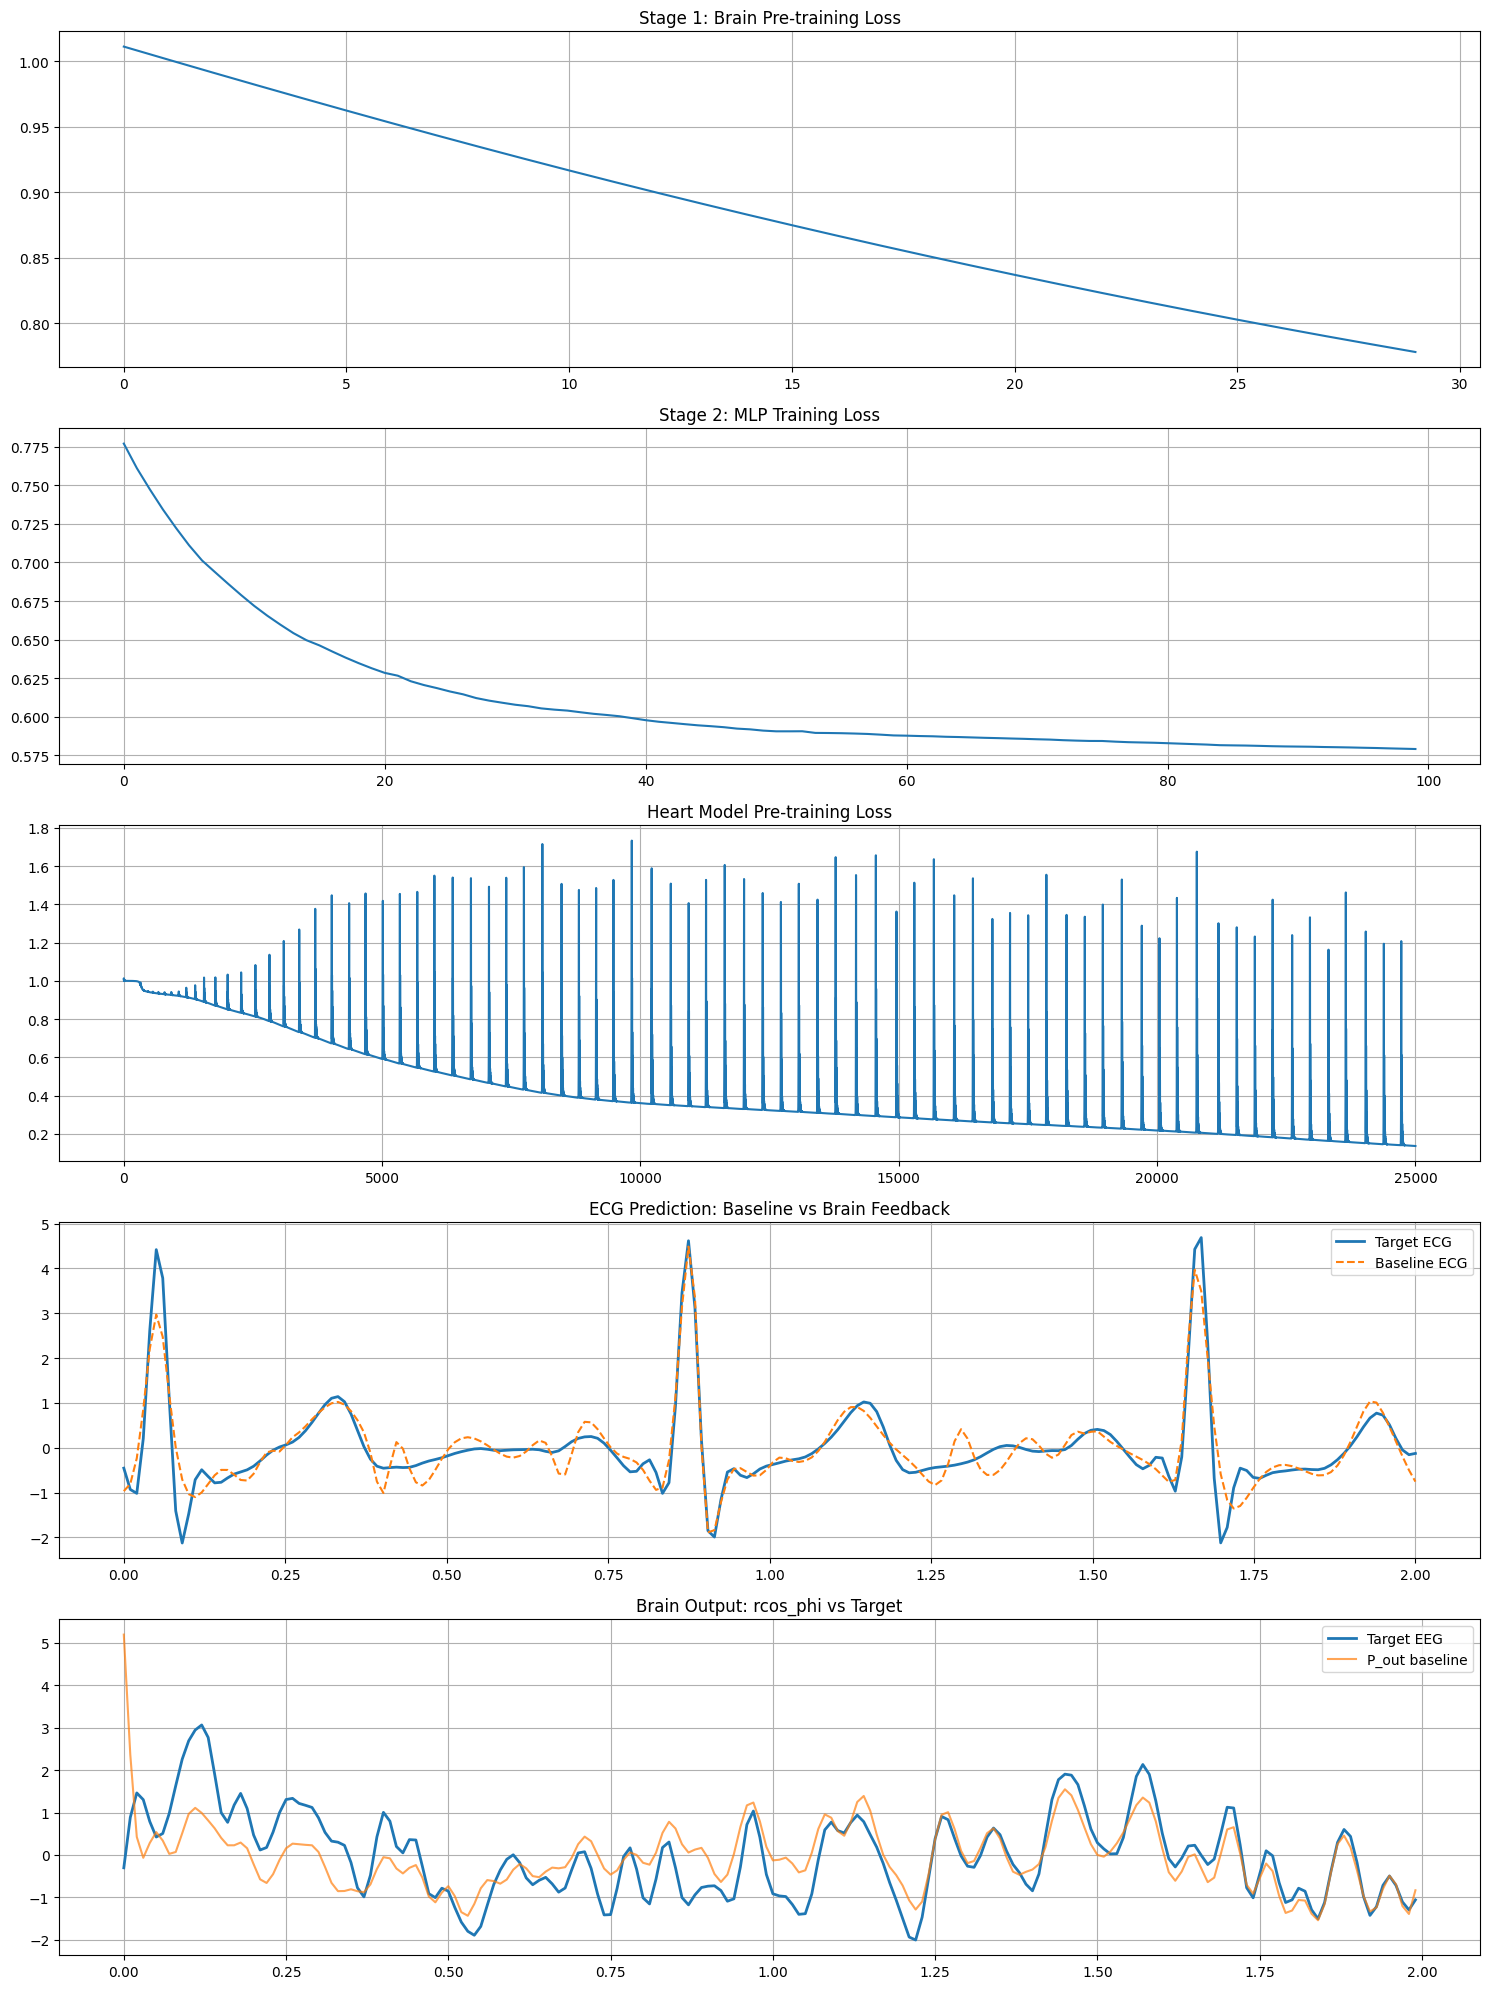

✅ COMPLETE! Check simulation_results/ folder


In [20]:
# ★★★ FINAL PREDICTION & PLOTTING ★★★
print("\n--- Final Predictions ---")
trained_heart_model.eval()
with torch.no_grad():
    # Baseline ECG (no feedback)
    sim_osc_baseline = simulate_coupled_oscillators(T=t_duration, dt=1/fs)
    predicted_ecg_baseline = trained_heart_model(
        torch.tensor(sim_osc_baseline, dtype=torch.float32).to(device)
    ).cpu().numpy().flatten()

    P_out_baseline = torch.sum(alpha_final * r_final * torch.cos(phi_final), axis=1).cpu().numpy()

# ★★★ PLOTTING ★★★
# FIX 4: axes[2] now shows heart model loss (was blank before)
fig, axes = plt.subplots(5, 1, figsize=(15, 20))

axes[0].plot(brain_losses)
axes[0].set_title('Stage 1: Brain Pre-training Loss')
axes[0].grid(True)

axes[1].plot(mlp_losses)
axes[1].set_title('Stage 2: MLP Training Loss')
axes[1].grid(True)

# FIX 4: Previously axes[2] was skipped (blank). Now shows heart model loss.
axes[2].plot(heart_losses)
axes[2].set_title('Heart Model Pre-training Loss')
axes[2].grid(True)

target_ecg = ecg_processed[::10]
timesteps = np.linspace(0, t_duration, len(target_ecg))

axes[3].plot(timesteps, target_ecg, label='Target ECG', linewidth=2)
axes[3].plot(timesteps, predicted_ecg_baseline, label='Baseline ECG', linestyle='--')
axes[3].set_title('ECG Prediction: Baseline vs Brain Feedback')
axes[3].legend()
axes[3].grid(True)

axes[4].plot(t, D_function(t), label='Target EEG', linewidth=2)
axes[4].plot(t, P_out_baseline, label='P_out baseline', alpha=0.7)
axes[4].set_title('Brain Output: rcos_phi vs Target')
axes[4].legend()
axes[4].grid(True)

plt.tight_layout()
plt.savefig(f"{results_folder}/full_feedback_result_idx{target_idx}.png", dpi=300, bbox_inches='tight')
plt.show()

np.savez(f"{results_folder}/results_idx{target_idx}.npz",
        brain_losses=brain_losses,
        mlp_losses=mlp_losses,
        heart_losses=heart_losses,
        rcos_phi_final=rcos_phi_final.detach().cpu().numpy(),
        P_out_baseline=P_out_baseline,
        predicted_ecg_baseline=predicted_ecg_baseline,
        target_ecg=target_ecg,
        target_eeg=D_function(t))

print("✅ COMPLETE! Check simulation_results/ folder")